<a href="https://colab.research.google.com/github/jvgarmatz/ia-ciberseguranca/blob/main/aula6_ueba_anomalias_process_mining_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Aula 6
## Detecção de anomalias, UEBA e SOC assistido (+ mineração de processos)

**Dupla:** `João Victor Garmatz`  ·  `João Danilo`

> Rodem as células na ordem.

Até agora treinamos modelos **com rótulos** (phishing, ataques). Hoje mudamos a chave: **não temos rótulos**. O objetivo é encontrar **comportamento anômalo** de usuários — a base do **UEBA** (*User and Entity Behavior Analytics*) — e depois **priorizar alertas** pensando no analista do SOC. Fechamos com **mineração de processos**, que acha *sequências* de ações fora do padrão.

Ferramentas: Isolation Forest, LOF e clustering para anomalia; um grafo de processos (directly-follows) para as sequências.

## 0. A base — um log corporativo (estilo CERT)

O *benchmark* clássico de UEBA é o **CERT Insider Threat (CMU)**: logs de logon, dispositivos (USB), arquivos e web por usuário. Mas ele é **sintético mesmo** e pesa 10–22 GB — inviável para baixar em aula. Então **geramos aqui um log equivalente**, com alguns *insiders* plantados.

> Importante: os *insiders* são plantados **só para avaliar no final** se os métodos funcionaram. **Não usamos essa informação para treinar** — no mundo real ela não existe. É exatamente o desafio do não supervisionado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

sns.set_theme(style='whitegrid')
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DOWNLOAD BASE ALUNOS

In [2]:
import pandas as pd
import gdown

# Link do Google Drive
link = 'https://drive.google.com/file/d/1H1kWZD1kD-O69JRoFkKC0dZkWsZoeh61/view?usp=sharing'

# Extrai o ID do arquivo e faz o download automático via gdown
file_id = link.split('/d/')[1].split('/')[0]
download_url = f'https://drive.google.com/uc?id={file_id}'
caminho_local = 'dados.csv'

gdown.download(download_url, caminho_local, quiet=False)

# Leitura do arquivo baixado
log = pd.read_csv(caminho_local, parse_dates=['timestamp'])
log['is_insider'] = log['is_insider'].astype(bool)

# ---- validação da estrutura ----
print('Dimensões:', log.shape)
print('Colunas   :', list(log.columns))
print('Período   :', log['timestamp'].min(), '->', log['timestamp'].max())
print('Usuários  :', log['user'].nunique(),
      '| insiders :', int(log.groupby('user')['is_insider'].max().sum()))
print('\nEventos por ação:')
print(log['acao'].value_counts().to_string())

esperado = {'user','timestamp','acao','pc','bytes','is_insider'}
faltando = esperado - set(log.columns)
print('\nSchema OK ✅' if not faltando else f'\n⚠️ faltando colunas: {faltando}')

log.head()

Downloading...
From (original): https://drive.google.com/uc?id=1H1kWZD1kD-O69JRoFkKC0dZkWsZoeh61
From (redirected): https://drive.google.com/uc?id=1H1kWZD1kD-O69JRoFkKC0dZkWsZoeh61&confirm=t&uuid=ba37c263-9c3c-4764-9e5f-f96fb5e1b795
To: /content/dados.csv
100%|██████████| 173M/173M [00:01<00:00, 112MB/s]


Dimensões: (3164418, 6)
Colunas   : ['user', 'timestamp', 'acao', 'pc', 'bytes', 'is_insider']
Período   : 2010-08-01 00:32:47 -> 2010-09-29 23:56:23
Usuários  : 814 | insiders : 47

Eventos por ação:
acao
web_browse     2943532
logon            49437
file_copy        47350
usb_connect      45164
logoff           40492
web_upload       38443

Schema OK ✅


,user,timestamp,acao,pc,bytes,is_insider
0,BSS0369,2010-08-01 00:32:47,logon,PC-7019,0,False
1,BSS0369,2010-08-01 00:36:43,usb_connect,PC-7019,0,False
2,BSS0369,2010-08-01 00:37:02,file_copy,PC-7019,0,False
3,BSS0369,2010-08-01 00:37:08,file_copy,PC-7019,0,False
4,BSS0369,2010-08-01 00:38:12,file_copy,PC-7019,0,False


## Parte A — UEBA: perfil de comportamento por usuário

A ideia do UEBA: em vez de olhar evento por evento, **construímos um perfil de cada usuário** (features que resumem seu comportamento) e procuramos quem **foge do padrão do grupo**.

In [3]:
log['hora'] = log.timestamp.dt.hour
log['fds']  = log.timestamp.dt.weekday >= 5
g = log.groupby('user')

perfil = pd.DataFrame({
    'n_eventos':        g.size(),
    'frac_offhours':    g.apply(lambda x: ((x.hora >= 20) | (x.hora < 6)).mean()),
    'frac_fds':         g['fds'].mean(),
    'n_usb':            g.apply(lambda x: (x.acao == 'usb_connect').sum()),
    'n_file_copy':      g.apply(lambda x: (x.acao == 'file_copy').sum()),
    'n_web_upload':     g.apply(lambda x: (x.acao == 'web_upload').sum()),
    'bytes_out':        g.apply(lambda x: x.loc[x.acao == 'web_upload', 'bytes'].sum()),
    'distinct_pcs':     g['pc'].nunique(),
    'n_distinct_acoes': g['acao'].nunique(),
})
gabarito = g['is_insider'].max()      # guardado SÓ para avaliação no final
print('Perfil (uma linha por usuário):', perfil.shape)
perfil.head()

/tmp/ipykernel_2909/2712720644.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'frac_offhours':    g.apply(lambda x: ((x.hora >= 20) | (x.hora < 6)).mean()),
/tmp/ipykernel_2909/2712720644.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'n_usb':            g.apply(lambda x: (x.acao == 'usb_connect').sum()),
/tmp/ipykernel_2909/2712720644.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on 

Perfil (uma linha por usuário): (814, 9)


,n_eventos,frac_offhours,frac_fds,n_usb,n_file_copy,n_web_upload,bytes_out,distinct_pcs,n_distinct_acoes
user,,,,,,,,,
AAF0535,709,0.000000,0.0,116,66,0,0,1,5
AAF0791,4074,0.000000,0.0,0,0,23,0,1,4
AAM0658,1302,0.155146,0.0,0,0,3,0,1,4
AAN0823,504,0.000000,0.0,0,0,0,0,1,3
AAV0450,504,0.000000,0.0,0,0,0,0,1,3


Vejamos como duas features comportamentais já separam visualmente alguns usuários.

**O que observar:** a maioria fica concentrada num canto (trabalho diurno, pouco upload) e alguns pontos se afastam. Anomalia = estar longe do comportamento típico. Vamos medir isso com três métodos.

### Padronização
Métodos baseados em distância/densidade (LOF) e mesmo o Isolation Forest lidam melhor com features na mesma escala.

In [4]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(perfil.values)
print('Matriz de perfis padronizada:', X.shape)

Matriz de perfis padronizada: (814, 9)


### Método 1 — Isolation Forest
Isola cada ponto com cortes aleatórios: pontos anômalos são **isolados com poucos cortes**. Devolve um score de anomalia por usuário.

In [5]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_SEED)
iso.fit(X)
perfil['score_iso'] = -iso.score_samples(X)   # maior = mais anômalo

<Axes: >

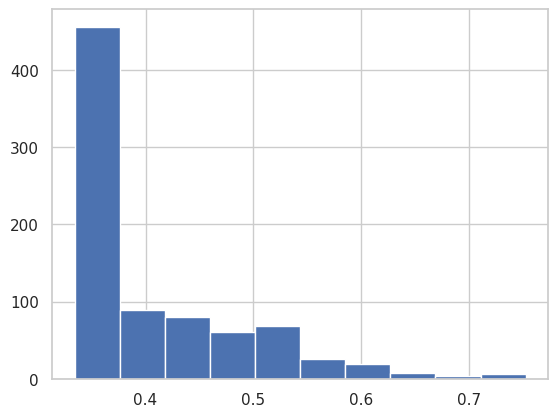

In [6]:
perfil.score_iso.hist()

In [7]:
perfil.score_iso.sort_values(ascending=False)

,score_iso
user,
BSS0369,0.753015
AJF0370,0.733345
MPM0220,0.732187
HSB0196,0.726621
DLM0051,0.722006
...,...
CBG0398,0.334290
MIL0255,0.334290
KBL0260,0.334290


### Método 2 — LOF (Local Outlier Factor)
Compara a densidade de cada ponto com a dos vizinhos: quem está numa região muito mais “vazia” que os vizinhos é anômalo.

In [8]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof.fit_predict(X)
perfil['score_lof'] = -lof.negative_outlier_factor_

/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


<Axes: >

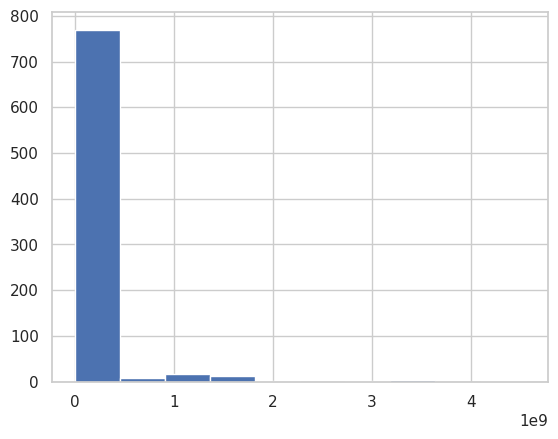

In [9]:
perfil.score_lof.hist()

In [10]:
perfil.score_lof.sort_values(ascending=False)

,score_lof
user,
BDB0453,4.550742e+09
SEJ0677,3.541265e+09
WDV0573,3.532524e+09
AJL0462,3.299006e+09
RTO0313,2.876273e+09
...,...
EHR0096,9.601076e-01
ECL0930,9.552434e-01
YCE0983,9.548644e-01


### Método 3 — Clustering (K-Means)
Agrupamos os perfis e medimos a **distância ao centro mais próximo**: quem está muito longe de qualquer grupo é candidato a anomalia.

In [11]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_SEED).fit(X)
dist = np.min(km.transform(X), axis=1)
perfil['score_cluster'] = dist

<Axes: >

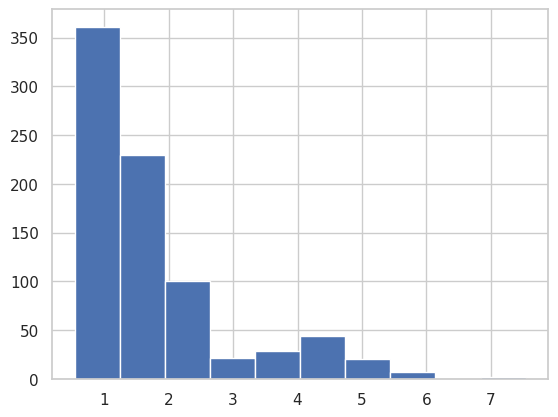

In [12]:
perfil.score_cluster.hist()

In [13]:
perfil.score_cluster.sort_values(ascending=False)

,score_cluster
user,
MCF0600,7.539636
BSS0369,7.333305
LCB0664,5.957123
AOK0844,5.898358
AJF0370,5.738252
...,...
BLB0114,0.622560
AIP0394,0.599562
IAT0263,0.598133


Vamos ver a distribuição dos scores do Isolation Forest e onde fica o corte de alerta.

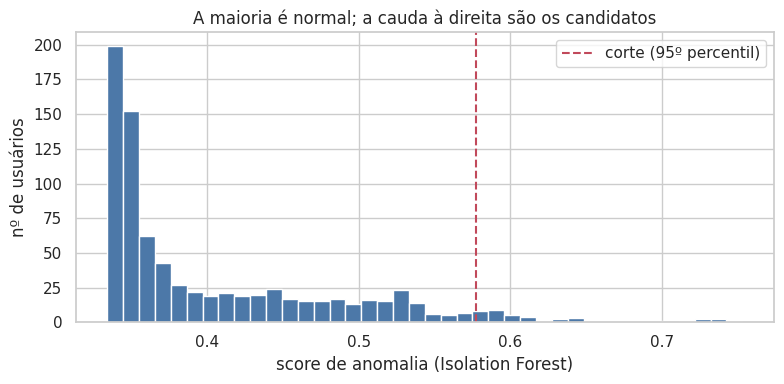

In [14]:
corte = perfil['score_iso'].quantile(0.95)
plt.figure(figsize=(8,4))
plt.hist(perfil['score_iso'], bins=40, color='#4C78A8')
plt.axvline(corte, ls='--', color='#C1495B', label='corte (95º percentil)')
plt.xlabel('score de anomalia (Isolation Forest)'); plt.ylabel('nº de usuários')
plt.title('A maioria é normal; a cauda à direita são os candidatos'); plt.legend(); plt.tight_layout(); plt.show()

### Os três métodos concordam?
Comparamos quem cada método coloca no topo. Concordância entre métodos aumenta a confiança no alerta.

In [15]:
topN = 12
tops = {m: set(perfil[m].sort_values(ascending=False).head(topN).index)
        for m in ['score_iso','score_lof','score_cluster']}
consenso = tops['score_iso'] & tops['score_lof'] & tops['score_cluster']
print(f'Top-{topN} de cada método:')
for m, s in tops.items(): print(f'  {m}: {sorted(s)}')
print(f'\nUsuários no topo dos TRÊS métodos (consenso): {sorted(consenso)}')

Top-12 de cada método:
  score_iso: ['AJF0370', 'BSS0369', 'DLM0051', 'EIS0041', 'HPH0075', 'HRB0351', 'HSB0196', 'IBB0359', 'LBH0942', 'MOH0273', 'MPM0220', 'WPR0368']
  score_lof: ['AJL0462', 'BDB0453', 'CEB0210', 'DMM0623', 'FBW0747', 'FLM0213', 'JRG0207', 'RTO0313', 'SEJ0677', 'VMJ0147', 'WDV0573', 'ZJE0857']
  score_cluster: ['AJF0370', 'AOK0844', 'ATE0869', 'BRM0995', 'BSS0369', 'CTR0341', 'HRL0540', 'HSB0196', 'LCB0664', 'MCF0600', 'MPM0220', 'RZC0746']

Usuários no topo dos TRÊS métodos (consenso): []


### Só agora usamos o gabarito — os métodos funcionaram?
No mundo real não temos essa resposta. Aqui, como plantamos os *insiders*, dá para medir **quantos** aparecem entre os mais anômalos (precision@k).

In [16]:
def precision_at_k(coluna, k):
    topo = perfil[coluna].sort_values(ascending=False).head(k).index
    return int(gabarito.loc[topo].sum())

total_ins = int(gabarito.sum())
print(f'Insiders plantados: {total_ins}\n')
print(f'{"método":<16}{"top-5":>8}{"top-10":>8}{"top-20":>8}')
for m in ['score_iso','score_lof','score_cluster']:
    print(f'{m:<16}{precision_at_k(m,5):>8}{precision_at_k(m,10):>8}{precision_at_k(m,20):>8}')

Insiders plantados: 47

método             top-5  top-10  top-20
score_iso              1       1       3
score_lof              0       1       1
score_cluster          1       2       2


## Parte B — Priorização de alertas e a fadiga do analista

Um SOC não consegue investigar todo mundo. O score vira uma **fila de alertas**: investiga-se do mais anômalo para o menos. Duas perguntas guiam tudo:
- **Onde cortar?** (quantos alertas por dia o time aguenta)
- **Como ordenar?** (para os casos reais chegarem ao topo)

### Combinando os métodos (ensemble por ranking)
Somar as posições (ranks) dos três métodos costuma ordenar melhor que qualquer um sozinho.

In [17]:
perfil['rank_ensemble'] = (perfil['score_iso'].rank() +
                           perfil['score_lof'].rank() +
                           perfil['score_cluster'].rank())
fila = perfil.sort_values('rank_ensemble', ascending=False).copy()
fila['is_insider'] = gabarito.loc[fila.index].values

print('FILA DE ALERTAS (top 15) — o SOC investiga de cima para baixo:')
fila[['score_iso','score_lof','score_cluster','is_insider']].head(15).round(2)

FILA DE ALERTAS (top 15) — o SOC investiga de cima para baixo:


,score_iso,score_lof,score_cluster,is_insider
user,,,,
LCB0664,0.63,2.36,5.96,False
MCF0600,0.63,2.31,7.54,True
WPR0368,0.66,3.70,4.58,False
BSS0369,0.75,1.75,7.33,False
HRB0351,0.69,1.92,5.21,False
OBH0499,0.61,1.93,4.95,False
IIW0249,0.58,2.02,4.82,False
HRL0540,0.61,1.70,5.29,False
MSS0001,0.53,3.67,5.14,False


### O trade-off da fadiga de alertas
Se o corte for **frouxo**, muitos alertas — a maioria falso positivo — e o analista se esgota. Se for **apertado**, poucos alertas, mas o risco de deixar um insider passar aumenta.

In [18]:
for k in [5, 10, 20, 40]:
    achou = precision_at_k('rank_ensemble', k)
    fp = k - achou
    print(f'Investigando top-{k:>2}: pega {achou}/{total_ins} insiders  |  {fp} alarmes falsos  '
          f'|  precisão da fila = {achou/k:.0%}')

Investigando top- 5: pega 1/47 insiders  |  4 alarmes falsos  |  precisão da fila = 20%
Investigando top-10: pega 1/47 insiders  |  9 alarmes falsos  |  precisão da fila = 10%
Investigando top-20: pega 3/47 insiders  |  17 alarmes falsos  |  precisão da fila = 15%
Investigando top-40: pega 4/47 insiders  |  36 alarmes falsos  |  precisão da fila = 10%


Comente o resultado aqui

* Os três métodos apresentaram resultados diferentes. Não houve nenhum usuário presente simultaneamente no Top-12 dos três métodos, indicando baixa concordância entre eles. O Isolation Forest encontrou 1 insider no Top-5 e 3 no Top-20, o LOF encontrou 0 no Top-5 e 1 no Top-20, e o clustering encontrou 1 no Top-5 e 2 no Top-20.

## Parte C — Mineração de processos: sequências fora do padrão

Até aqui olhamos *quanto* cada usuário faz. Agora olhamos *em que ordem*. Na **mineração de processos**:
- cada **caso** = um usuário num dia;
- o **trace** = a sequência de ações daquele dia (logon → web_browse → file_read → …).

Descobrimos o **fluxo típico** e marcamos os caminhos raros — um `usb_connect → file_copy → web_upload` de madrugada não se parece com o dia a dia de ninguém.

In [19]:
# Para a mineração de processos: enxugar o excesso de 'web_browse'.
# Mantemos no máximo 3 web_browse seguidos por usuário-dia (o resto é ruído repetido).
log_proc = log.sort_values('timestamp').copy()
log_proc['data'] = log_proc['timestamp'].dt.date

def limita_browse(g, maximo=3):
    eh_browse = g['acao'].eq('web_browse')
    # conta web_browse consecutivos dentro do dia
    grupo = (~eh_browse).cumsum()
    ordem = g.groupby(grupo).cumcount()
    manter = ~eh_browse | (ordem < maximo)
    return g[manter]

log_proc = (log_proc.groupby(['user','data'], group_keys=False)
                    .apply(limita_browse)
                    .reset_index(drop=True))

print('Antes :', len(log), 'eventos')
print('Depois:', len(log_proc), 'eventos (para a mineração de processos)')
print(log_proc['acao'].value_counts().to_string())

/tmp/ipykernel_2909/3888107682.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(limita_browse)


Antes : 3164418 eventos
Depois: 444359 eventos (para a mineração de processos)
acao
web_browse     223473
logon           49437
file_copy       47350
usb_connect     45164
logoff          40492
web_upload      38443


In [20]:
log['data'] = log.timestamp.dt.date
traces = log.groupby(['user','data'])['acao'].apply(list)

variantes = traces.apply(lambda s: ' > '.join(s)).value_counts()
print(f'Casos (usuário-dia): {len(traces)}  |  variantes distintas: {len(variantes)}\n')
print('Variantes mais comuns (o comportamento "normal"):')
for v, c in variantes.head(3).items():
    print(f'  ({c}x)  {v[:90]}...')

Casos (usuário-dia): 34379  |  variantes distintas: 13284

Variantes mais comuns (o comportamento "normal"):
  (4557x)  logon > web_browse > web_browse > web_browse > web_browse > web_browse > web_browse > web_...
  (4180x)  logon > web_browse > web_browse > web_browse > web_browse > web_browse > web_browse > web_...
  (3366x)  logon > web_browse > web_browse > web_browse > web_browse > web_browse > web_browse > web_...


### O grafo de processo (directly-follows)
Contamos quantas vezes cada ação é seguida diretamente por outra. É o “mapa” do processo.

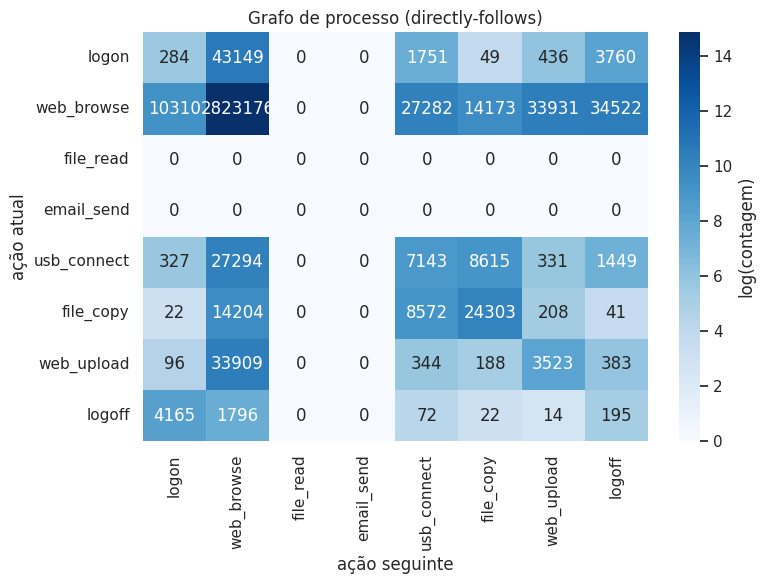

In [21]:
from collections import Counter
trans = Counter()
for s in traces:
    for a, b in zip(s, s[1:]):
        trans[(a, b)] += 1

acoes = ['logon','web_browse','file_read','email_send','usb_connect','file_copy','web_upload','logoff']
M = pd.DataFrame(0, index=acoes, columns=acoes, dtype=float)
for (a, b), c in trans.items():
    if a in acoes and b in acoes: M.loc[a, b] = c

plt.figure(figsize=(8,6))
sns.heatmap(np.log1p(M), annot=M.astype(int), fmt='d', cmap='Blues', cbar_kws={'label':'log(contagem)'})
plt.xlabel('ação seguinte'); plt.ylabel('ação atual'); plt.title('Grafo de processo (directly-follows)')
plt.tight_layout(); plt.show()

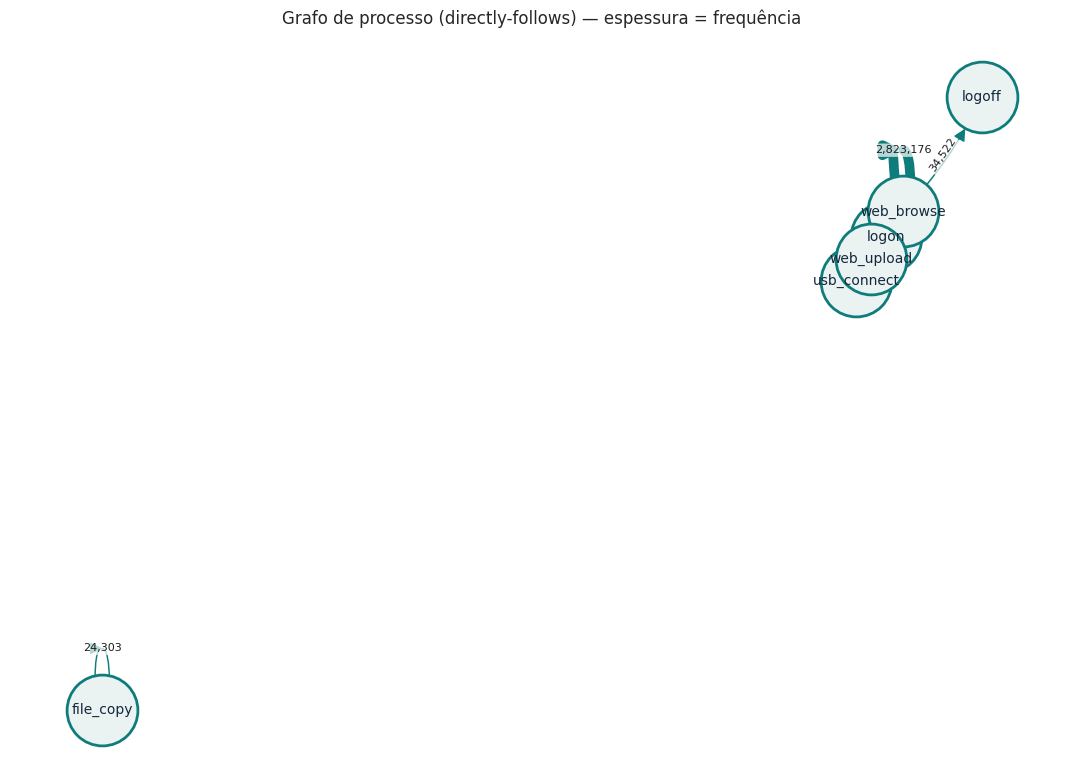

In [22]:
from collections import Counter
import networkx as nx

trans = Counter()
for s in traces:
    for a, b in zip(s, s[1:]):
        trans[(a, b)] += 1

# opcional: esconder transições muito raras para não poluir o grafo
tot = sum(trans.values())
MIN_FRAC = 0.005   # mostra só transições com >= 0.5% do total
arestas = {(a, b): c for (a, b), c in trans.items() if c/tot >= MIN_FRAC}

G = nx.DiGraph()
for (a, b), c in arestas.items():
    G.add_edge(a, b, weight=c)

# posição dos nós (seed fixa para o layout não mudar a cada execução)
pos = nx.spring_layout(G, seed=42, k=1.2)

# espessura das setas proporcional à frequência
pesos = [G[u][v]['weight'] for u, v in G.edges()]
wmax = max(pesos)
larguras = [1 + 6*(w/wmax) for w in pesos]

plt.figure(figsize=(11, 8))
nx.draw_networkx_nodes(G, pos, node_size=2600, node_color='#EAF3F2', edgecolors='#0E7C7B', linewidths=2)
nx.draw_networkx_labels(G, pos, font_size=10, font_color='#14283C')
nx.draw_networkx_edges(G, pos, width=larguras, edge_color='#0E7C7B',
                       arrowsize=18, arrowstyle='-|>',
                       connectionstyle='arc3,rad=0.08',  # curva leve p/ separar ida e volta
                       node_size=2600, min_source_margin=18, min_target_margin=18)
# rótulo com a contagem em cada seta
rotulos = {(u, v): f"{G[u][v]['weight']:,}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=rotulos, font_size=8, label_pos=0.5,
                             bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))

plt.title('Grafo de processo (directly-follows) — espessura = frequência')
plt.axis('off'); plt.tight_layout(); plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 46.3 MB/s eta 0:00:00


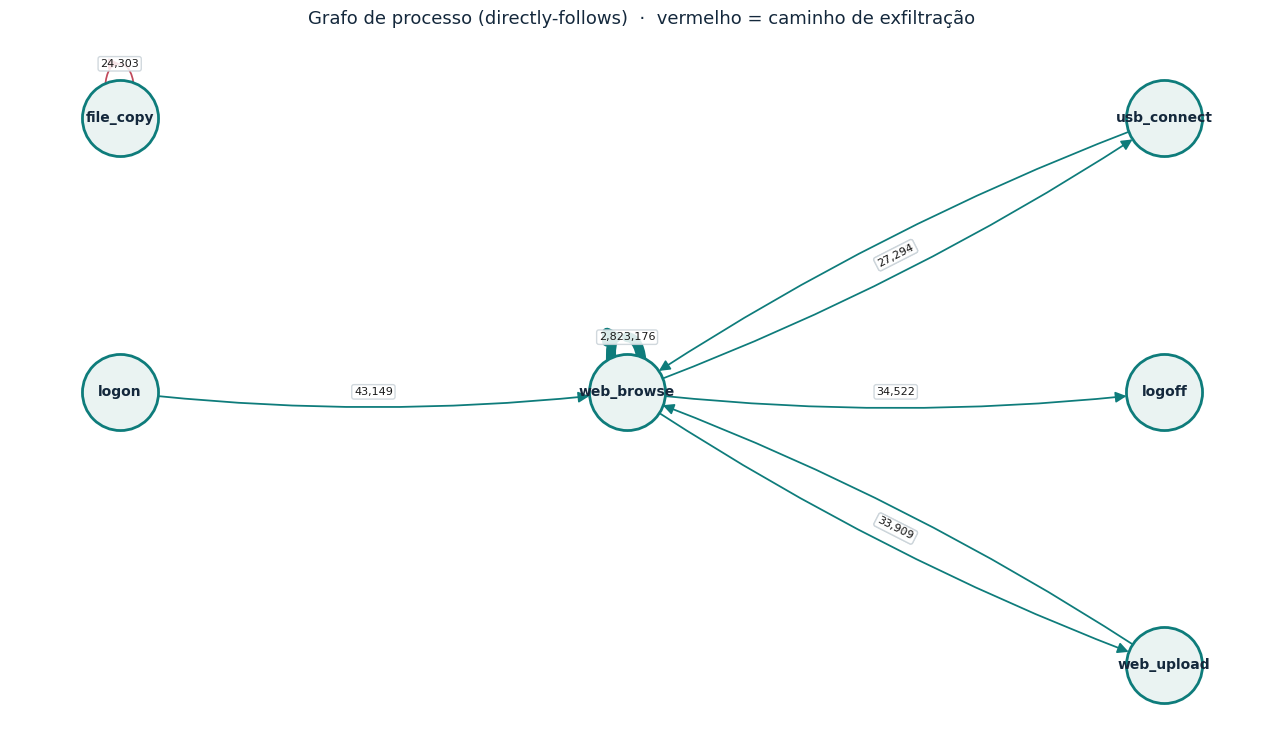

In [23]:
!apt-get -qq install -y graphviz > /dev/null && pip install -q pygraphviz

from collections import Counter
import networkx as nx

trans = Counter()
for s in traces:
    for a, b in zip(s, s[1:]):
        trans[(a, b)] += 1

tot = sum(trans.values())
MIN_FRAC = 0.005                     # esconde transições < 0.5% (ajuste)
arestas = {(a, b): c for (a, b), c in trans.items() if c/tot >= MIN_FRAC}

G = nx.DiGraph()
for (a, b), c in arestas.items():
    G.add_edge(a, b, weight=c)

# layout hierárquico esquerda->direita (fluxograma)
pos = nx.nx_agraph.graphviz_layout(G, prog='dot', args='-Grankdir=LR -Gnodesep=0.6 -Granksep=1.4')

# cor/espessura das setas por frequência
pesos = [G[u][v]['weight'] for u, v in G.edges()]
wmax = max(pesos)
larguras = [1.2 + 6*(w/wmax) for w in pesos]

# destaca o caminho de exfiltração em vermelho
EXFIL = {('logon','usb_connect'),('usb_connect','file_copy'),
         ('file_copy','web_upload'),('file_read','file_copy'),('file_copy','file_copy')}
cores = ['#C1495B' if (u,v) in EXFIL else '#0E7C7B' for u,v in G.edges()]

plt.figure(figsize=(13, 7.5))
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='#EAF3F2',
                       edgecolors='#0E7C7B', linewidths=2)
nx.draw_networkx_labels(G, pos, font_size=10, font_color='#14283C', font_weight='bold')
nx.draw_networkx_edges(G, pos, width=larguras, edge_color=cores,
                       arrowsize=16, arrowstyle='-|>',
                       connectionstyle='arc3,rad=0.06',
                       node_size=3000, min_source_margin=20, min_target_margin=20)
rotulos = {(u, v): f"{G[u][v]['weight']:,}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=rotulos, font_size=8, label_pos=0.5,
                             bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#C9D2D8', alpha=0.85))

plt.title('Grafo de processo (directly-follows)  ·  vermelho = caminho de exfiltração',
          fontsize=13, color='#14283C')
plt.axis('off'); plt.tight_layout(); plt.show()

In [24]:
# Variantes = sequências distintas de ações por usuário-dia
variantes = traces.apply(tuple).value_counts()

caminho_comum = list(variantes.index[0])     # a variante que mais se repete
caminho_raro  = list(variantes.index[-1])    # uma das que aparecem só 1x

print(f'Caminho MAIS COMUM  ({variantes.iloc[0]}x):')
print('  ' + ' -> '.join(caminho_comum[:20]) + (' ...' if len(caminho_comum) > 20 else ''))
print(f'\nCaminho MAIS RARO  ({variantes.iloc[-1]}x):')
print('  ' + ' -> '.join(caminho_raro[:20]) + (' ...' if len(caminho_raro) > 20 else ''))

Caminho MAIS COMUM  (4557x):
  logon -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse ...

Caminho MAIS RARO  (1x):
  logon -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_upload -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse -> web_browse ...


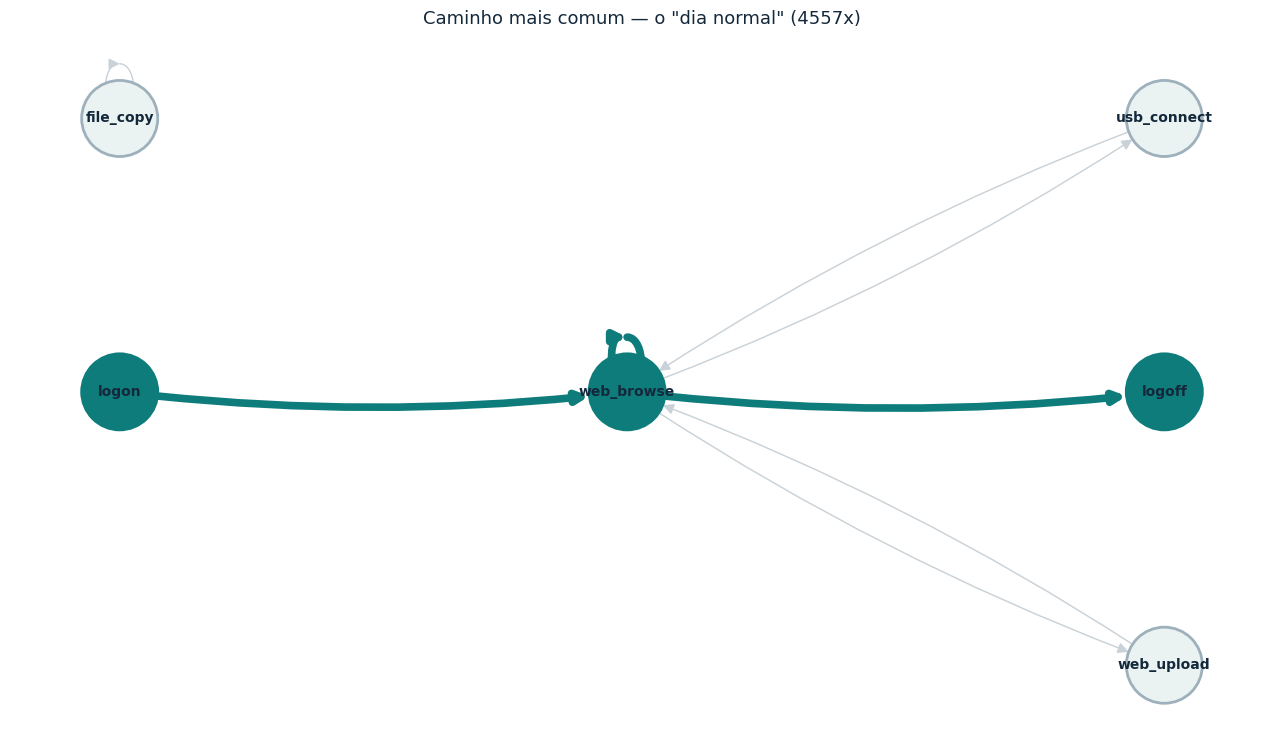

In [25]:
from collections import Counter
import networkx as nx

def desenhar_grafo(traces, caminho_destaque, titulo, cor_destaque, min_frac=0.005):
    trans = Counter()
    for s in traces:
        for a, b in zip(s, s[1:]):
            trans[(a, b)] += 1
    tot = sum(trans.values())
    arestas = {(a, b): c for (a, b), c in trans.items() if c/tot >= min_frac}

    G = nx.DiGraph()
    for (a, b), c in arestas.items():
        G.add_edge(a, b, weight=c)

    # arestas do caminho a destacar (pares consecutivos da sequência)
    destaque = set(zip(caminho_destaque, caminho_destaque[1:]))
    # garante que as arestas do caminho apareçam mesmo se forem raras
    for e in destaque:
        if e not in G.edges() and e[0] in G and e[1] in G:
            G.add_edge(*e, weight=trans.get(e, 1))

    pos = nx.nx_agraph.graphviz_layout(G, prog='dot', args='-Grankdir=LR -Gnodesep=0.6 -Granksep=1.4')
    wmax = max(d['weight'] for _,_,d in G.edges(data=True))

    larguras, cores = [], []
    for u, v in G.edges():
        if (u, v) in destaque:
            larguras.append(5.5); cores.append(cor_destaque)
        else:
            larguras.append(1.0 + 4*(G[u][v]['weight']/wmax)); cores.append('#C9D2D8')  # cinza claro

    # nós do caminho ganham cor; os demais ficam neutros
    nos_destaque = set(caminho_destaque)
    node_colors = [cor_destaque if n in nos_destaque else '#EAF3F2' for n in G.nodes()]
    node_edges  = [cor_destaque if n in nos_destaque else '#9DB0BC' for n in G.nodes()]

    plt.figure(figsize=(13, 7.5))
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=node_colors,
                           edgecolors=node_edges, linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='#14283C')
    nx.draw_networkx_edges(G, pos, width=larguras, edge_color=cores,
                           arrowsize=16, arrowstyle='-|>', connectionstyle='arc3,rad=0.06',
                           node_size=3000, min_source_margin=20, min_target_margin=20)
    plt.title(titulo, fontsize=13, color='#14283C')
    plt.axis('off'); plt.tight_layout(); plt.show()

# ---- Célula A: caminho MAIS COMUM (verde) ----
desenhar_grafo(traces, caminho_comum,
               f'Caminho mais comum — o "dia normal" ({variantes.iloc[0]}x)',
               cor_destaque='#0E7C7B')

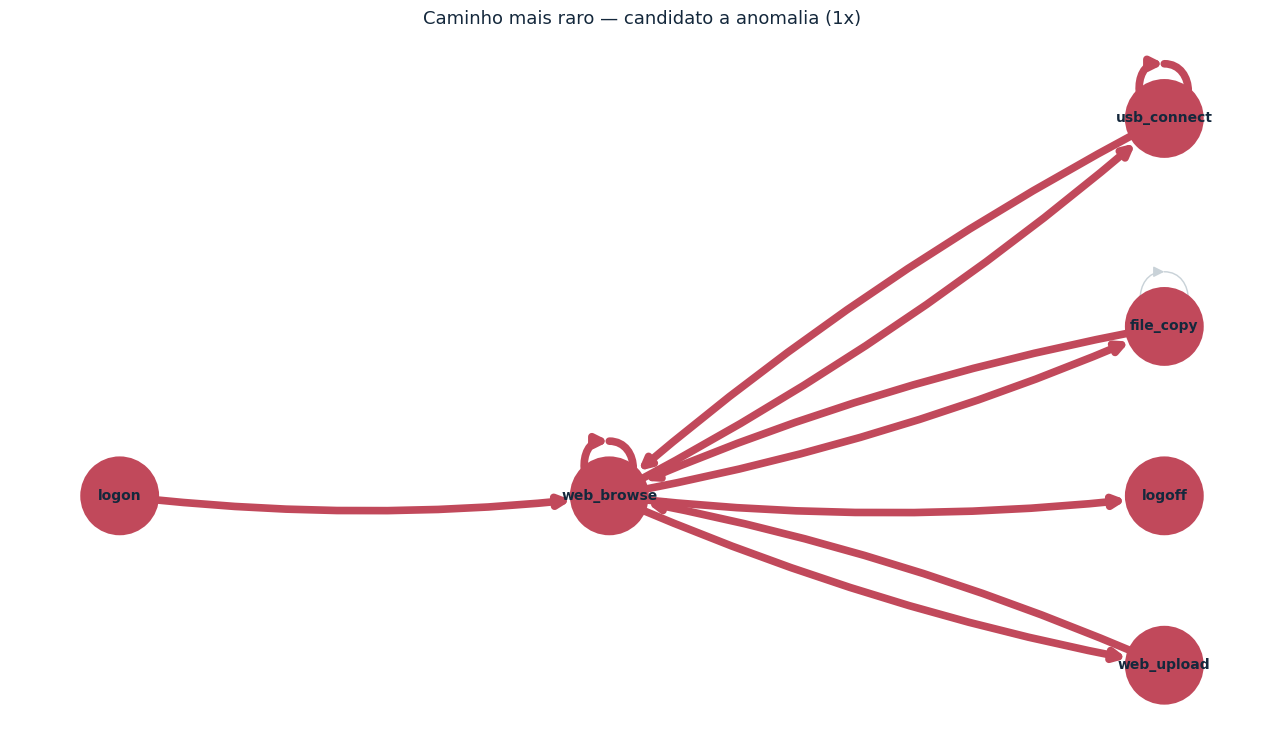

In [26]:
# ---- Célula B: caminho MAIS RARO (vermelho) ----
desenhar_grafo(traces, caminho_raro,
               f'Caminho mais raro — candidato a anomalia ({variantes.iloc[-1]}x)',
               cor_destaque='#C1495B')

### Escore de “surpresa” por caso
Damos a cada caso uma nota pela **raridade das suas transições** (transição rara = muita surpresa). Casos muito surpreendentes são anomalias de processo.

In [27]:
import math
tot = sum(trans.values())
prob = {k: v/tot for k, v in trans.items()}

def surpresa(seq):
    ps = [prob[(a,b)] for a, b in zip(seq, seq[1:])]
    return float(np.mean([-math.log2(p) for p in ps])) if ps else 0.0

casos = traces.reset_index()
casos['surpresa'] = traces.apply(surpresa).values
casos['is_insider'] = casos['user'].isin(set(log[log.is_insider].user)).values

top_casos = casos.sort_values('surpresa', ascending=False).head(40)
print('Casos (usuário-dia) mais surpreendentes:')
top_casos[['user','data','surpresa','is_insider']].round(2)

Casos (usuário-dia) mais surpreendentes:


,user,data,surpresa,is_insider
23476,NAF0326,2010-09-08,12.63,False
15766,JAJ0849,2010-08-21,11.56,False
2680,ASV0946,2010-09-02,11.56,False
28320,RUM0880,2010-09-01,11.56,False
30818,TDG0962,2010-08-09,10.60,False
9869,EIS0041,2010-08-27,10.56,False
20372,LJR0523,2010-08-07,10.10,False
9700,EHB0420,2010-09-18,9.70,False
16369,JDF0593,2010-09-18,9.70,False
24942,OBH0499,2010-09-18,9.70,False


### A mineração de processos concorda com o UEBA?

In [28]:
lim = casos['surpresa'].quantile(0.95)
flag = casos[casos['surpresa'] >= lim]
print(f'Nos 5% de casos mais surpreendentes: {flag.is_insider.mean():.0%} são dias de insider '
      f'(na base toda, apenas {casos.is_insider.mean():.0%}).')
print('Ou seja: olhar a SEQUÊNCIA das ações destaca os mesmos usuários de risco — por um caminho diferente do UEBA.')

Nos 5% de casos mais surpreendentes: 9% são dias de insider (na base toda, apenas 5%).
Ou seja: olhar a SEQUÊNCIA das ações destaca os mesmos usuários de risco — por um caminho diferente do UEBA.


### Por que usar os dois juntos
- **UEBA (features):** pega quem faz *volume/horário* fora do padrão. Pode não ver um ataque “discreto”.
- **Mineração de processos (sequência):** pega *ordens de ação* estranhas, mesmo com volume normal.
- **No SOC:** combinados, cobrem mais tipos de ameaça e ainda **explicam** o alerta (“este usuário fez copy→upload de madrugada”), o que ajuda o analista a decidir rápido.

## Discussão (respondam no notebook)
- Por que **não** usamos o rótulo de insider para treinar? O que muda em relação às aulas anteriores?
  * Não usamos o rótulo de insider porque os métodos utilizados são não supervisionados. Eles aprendem o comportamento considerado normal e procuram usuários ou atividades que fogem desse padrão. O rótulo foi usado somente depois, para avaliar se os métodos conseguiram encontrar os insiders. Aqui, o sistema precisa detectar ameaças desconhecidas, mesmo quando não existe um histórico confiável de usuários maliciosos.

- Seu time só investiga 10 alertas/dia. Que corte você usaria e o que aceita perder?
  * Usaríamos o corte no Top-10 da fila de alertas, pois essa é a capacidade diária da equipe. Porém, aceitaria o risco de deixar muitos insiders passarem: nesse experimento, apenas 1 dos 47 insiders apareceu entre os 10 primeiros alertas.
  Também seria necessário melhorar o modelo antes de colocá-lo em produção, pois 9 dos 10 alertas investigados seriam falsos positivos. A prioridade seria reduzir os falsos positivos e aumentar a presença de insiders no topo da fila.
- Cite um ataque que o **UEBA** pegaria e um que só a **mineração de processos** pegaria.
  * O **UEBA** poderia identificar um usuário que normalmente acessa poucos arquivos durante o horário comercial, mas de repente começa a acessar centenas de arquivos de madrugada. Nesse caso, o volume e o horário seriam diferentes do comportamento normal.
  A mineração de processos poderia identificar uma sequência suspeita como:
  ***logon → usb_connect → file_copy → web_upload***. Mesmo que a quantidade total de ações não fosse muito alta, essa ordem de eventos indicaria uma possível cópia e exfiltração de dados.

- Que outra feature de comportamento você adicionaria ao perfil de usuário?
  * Adicionaríamos a quantidade de dados transferidos por usuário, principalmente em uploads e cópias para dispositivos USB. Também seria útil registrar o endereço IP ou país de origem, o dispositivo utilizado, tentativas de login malsucedidas e alterações recentes de privilégios.
  Essas informações ajudariam a diferenciar uma atividade realmente suspeita de um comportamento apenas fora do padrão estatístico.

## Checklist do entregável de hoje
- [x] Log de eventos carregado e perfis de usuário construídos (UEBA)
- [x] Anomalias detectadas com Isolation Forest, LOF e clustering
- [x] Limiar calibrado e métodos comparados (precision@k com o gabarito)
- [x] Fila de alertas priorizada + análise da fadiga de alertas
- [x] Mineração de processos: grafo, variantes e escore de surpresa
- [ ] Respostas da discussão registradas no notebook

**Próxima aula:** pipeline reprodutível e consolidação — preparação para a AV1.